# 03 — Scenario 2: Parametric vs Non-Parametric Models

Goal: compare parametric and non-parametric classifiers on the same
`building_floor` target, using the official validation split as the held-out
test set. The comparison uses identical preprocessing and writes all model
diagnostics to fixed report paths for final interpretation.

In [1]:
# --- bootstrap: make src/ importable when notebook started outside `uv run` ---
import sys
from pathlib import Path

_HERE = Path.cwd()
for parent in [_HERE, *_HERE.parents]:
    if (parent / "src" / "ujiindoorloc").is_dir():
        if str(parent / "src") not in sys.path:
            sys.path.insert(0, str(parent / "src"))
        break

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning, module="sklearn")

In [2]:
import joblib
import numpy as np
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from ujiindoorloc.constants import COMBINED_TARGET, FIGURES_DIR, MODELS_DIR, TABLES_DIR
from ujiindoorloc.data_loading import load_raw_data, split_features_targets
from ujiindoorloc.preprocessing import prepare_classification_data
from ujiindoorloc import modeling as M
from ujiindoorloc import evaluation as E
from ujiindoorloc import plots as P
from ujiindoorloc.reporting import ensure_report_dirs, save_table

ensure_report_dirs()
MODELS_DIR.mkdir(parents=True, exist_ok=True)

In [3]:
raw = load_raw_data()
split = split_features_targets(raw.train, raw.valid, target_name=COMBINED_TARGET)
prepared = prepare_classification_data(split.X_train, split.X_valid)

Xs_tr, Xs_va = prepared.X_train_scaled, prepared.X_valid_scaled
Xt_tr, Xt_va = prepared.X_train_tree,   prepared.X_valid_tree
y_tr, y_va = np.asarray(split.y_train), np.asarray(split.y_valid)
print("scaled :", Xs_tr.shape, Xs_va.shape)
print("tree   :", Xt_tr.shape, Xt_va.shape)

scaled : (19937, 465) (1111, 465)
tree   : (19937, 465) (1111, 465)


## Model groups definition

Parametric models assume a fixed functional or distributional form
(Logistic Regression, LDA, QDA). Non-parametric models adapt more directly
to the training samples (kNN, Decision Tree, Random Forest). Each spec keeps
its family label so the final selection can compare best-in-family models.

In [4]:
specs = [
    {
        "name": "logistic_regression",
        "family": "parametric",
        "model": Pipeline([
            ("scaler", StandardScaler()),
            ("classifier", M.build_logistic_regression()),
        ]),
        "X_train": Xs_tr,
        "X_valid": Xs_va,
    },
    {
        "name": "lda",
        "family": "parametric",
        "model": M.build_lda(),
        "X_train": Xs_tr,
        "X_valid": Xs_va,
    },
    {
        "name": "qda_pca50",
        "family": "parametric",
        "model": M.build_pca_qda_pipeline(50),
        "X_train": Xs_tr,
        "X_valid": Xs_va,
    },
    {
        "name": "knn",
        "family": "non_parametric",
        "model": M.build_knn(),
        "X_train": Xs_tr,
        "X_valid": Xs_va,
    },
    {
        "name": "decision_tree",
        "family": "non_parametric",
        "model": Pipeline([("classifier", M.build_decision_tree())]),
        "X_train": Xt_tr,
        "X_valid": Xt_va,
    },
    {
        "name": "random_forest",
        "family": "non_parametric",
        "model": Pipeline([("classifier", M.build_random_forest())]),
        "X_train": Xt_tr,
        "X_valid": Xt_va,
    },
]
family_by_model = {spec["name"]: spec["family"] for spec in specs}
classification_report_paths = {
    "logistic_regression": "scenario_2_classification_report_logistic_regression.csv",
    "lda": "scenario_2_classification_report_lda.csv",
    "qda_pca50": "scenario_2_classification_report_qda_pca50.csv",
    "knn": "scenario_2_classification_report_knn.csv",
    "decision_tree": "scenario_2_classification_report_decision_tree.csv",
    "random_forest": "scenario_2_classification_report_random_forest.csv",
}
confusion_matrix_paths = {
    "logistic_regression": "scenario_2_confusion_matrix_logistic_regression.png",
    "lda": "scenario_2_confusion_matrix_lda.png",
    "qda_pca50": "scenario_2_confusion_matrix_qda_pca50.png",
    "knn": "scenario_2_confusion_matrix_knn.png",
    "decision_tree": "scenario_2_confusion_matrix_decision_tree.png",
    "random_forest": "scenario_2_confusion_matrix_random_forest.png",
}
pd.DataFrame([{k: v for k, v in spec.items() if k != "model"} for spec in specs])

,name,family,X_train,X_valid
0,logistic_regression,parametric,"[[-0.029975820457130407, -0.030760034963918565...","[[-0.029975820457130407, -0.030760034963918565..."
1,lda,parametric,"[[-0.029975820457130407, -0.030760034963918565...","[[-0.029975820457130407, -0.030760034963918565..."
2,qda_pca50,parametric,"[[-0.029975820457130407, -0.030760034963918565...","[[-0.029975820457130407, -0.030760034963918565..."
3,knn,non_parametric,"[[-0.029975820457130407, -0.030760034963918565...","[[-0.029975820457130407, -0.030760034963918565..."
4,decision_tree,non_parametric,"[[-110, -110, -110, -110, -110, -110, -110, -1...","[[-110, -110, -110, -110, -110, -110, -110, -1..."
5,random_forest,non_parametric,"[[-110, -110, -110, -110, -110, -110, -110, -1...","[[-110, -110, -110, -110, -110, -110, -110, -1..."


## Train and evaluate

Every successful model writes a classification report and confusion matrix
immediately. Failures are logged and skipped so one unstable classifier does
not block the full scenario.

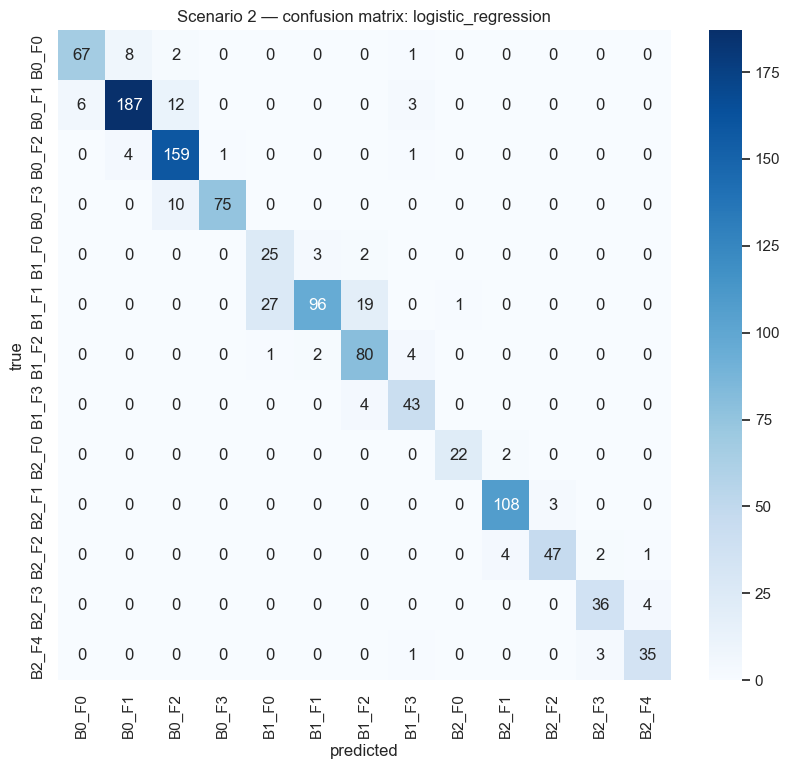

logistic_regression       family=parametric     bal_acc=0.885 macro_f1=0.870 fit=0.2s


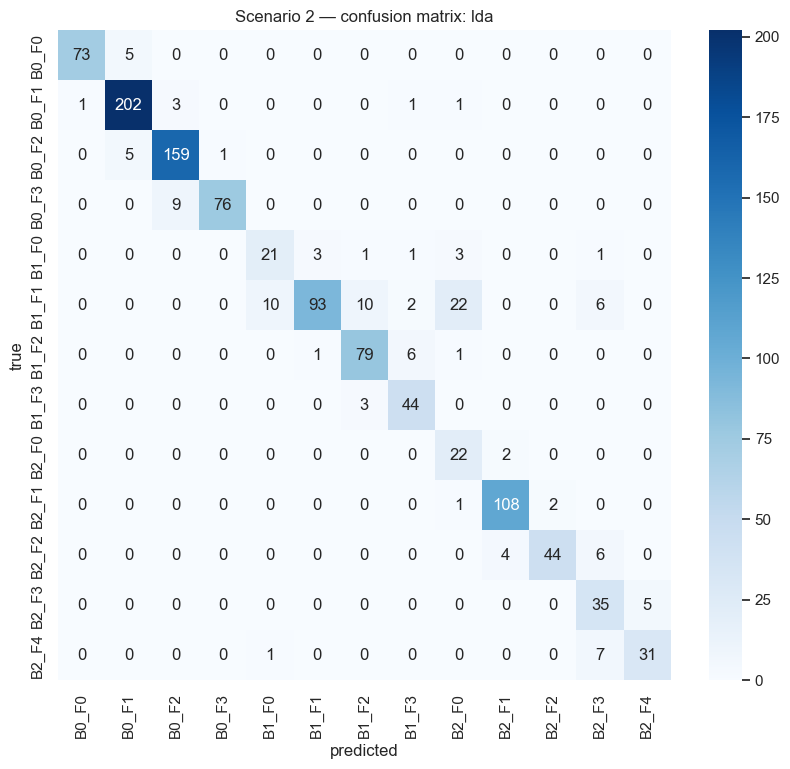

lda                       family=parametric     bal_acc=0.872 macro_f1=0.847 fit=0.3s


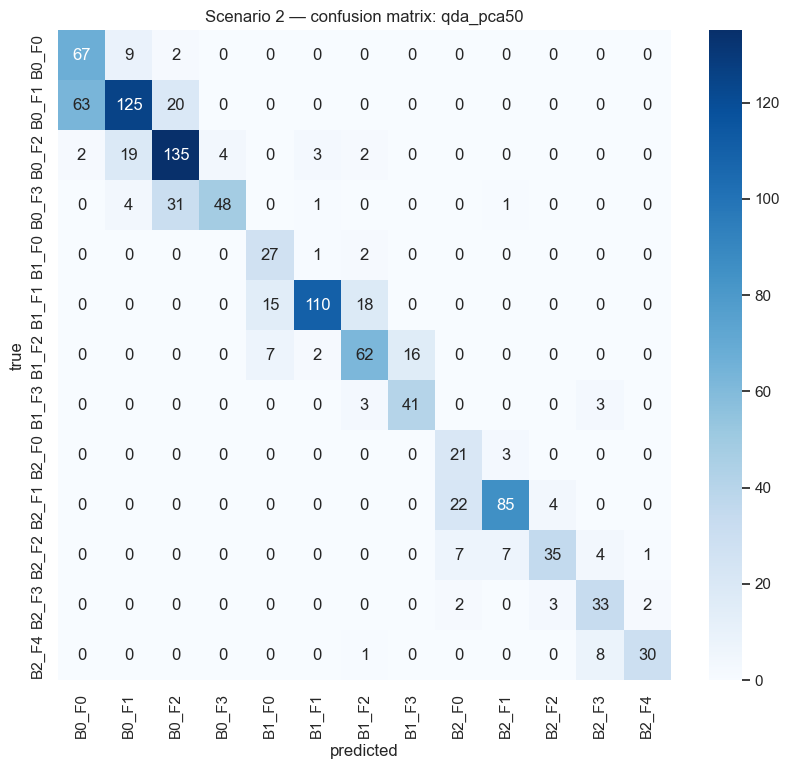

qda_pca50                 family=parametric     bal_acc=0.768 macro_f1=0.731 fit=0.1s


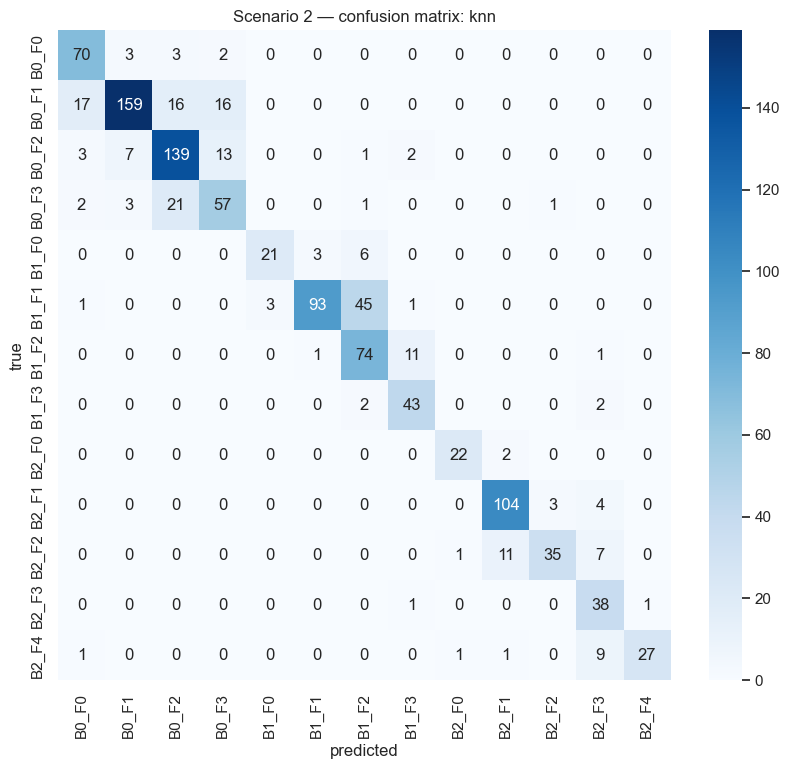

knn                       family=non_parametric bal_acc=0.803 macro_f1=0.793 fit=0.0s


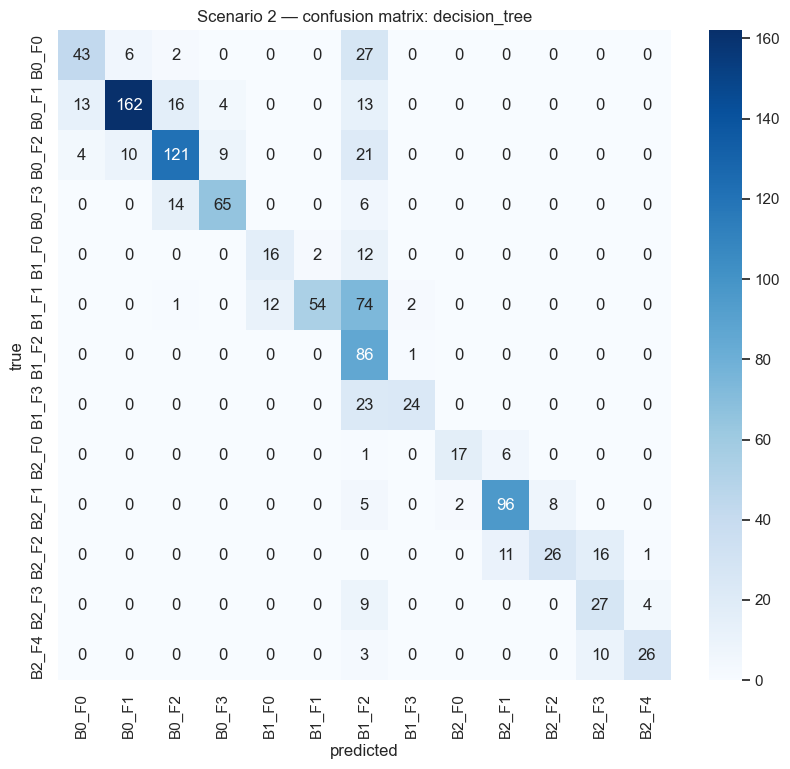

decision_tree             family=non_parametric bal_acc=0.664 macro_f1=0.676 fit=0.3s


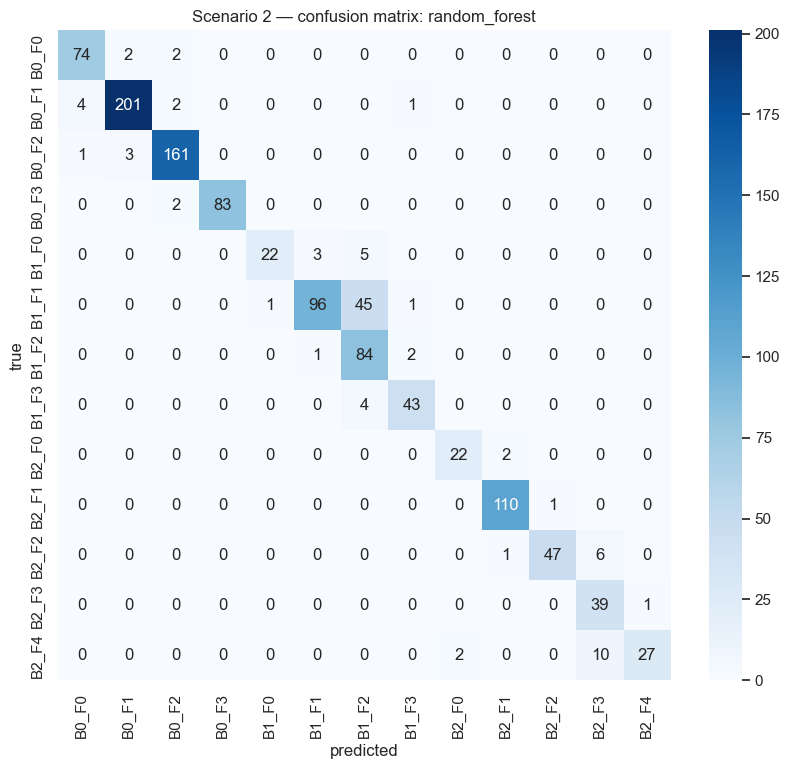

random_forest             family=non_parametric bal_acc=0.892 macro_f1=0.892 fit=0.4s


In [5]:
results = []
fitted_models = {}

for spec in specs:
    name = spec["name"]
    model = spec["model"]
    try:
        result = E.evaluate_classifier(
            model,
            spec["X_train"],
            y_tr,
            spec["X_valid"],
            y_va,
            name=name,
        )
        report_df = E.classification_report_to_dataframe(
            y_va, result.y_pred, labels=result.classes,
        )
        save_table(report_df, classification_report_paths[name])
        P.plot_confusion_matrix(
            result,
            FIGURES_DIR / confusion_matrix_paths[name],
            title=f"Scenario 2 — confusion matrix: {name}",
        )
        results.append(result)
        fitted_models[name] = model
        print(
            f"{name:25s} family={spec['family']:14s} "
            f"bal_acc={result.metrics['balanced_accuracy']:.3f} "
            f"macro_f1={result.metrics['macro_f1']:.3f} "
            f"fit={result.fit_seconds:.1f}s"
        )
    except Exception as exc:
        print(f"{name:25s}  FAILED: {type(exc).__name__}: {exc}")

## Raw QDA attempt

Raw QDA is theoretically parametric but numerically fragile in this
high-dimensional correlated WAP space. We attempt it once, save diagnostics
only if it succeeds, and otherwise keep the failure as an expected result.

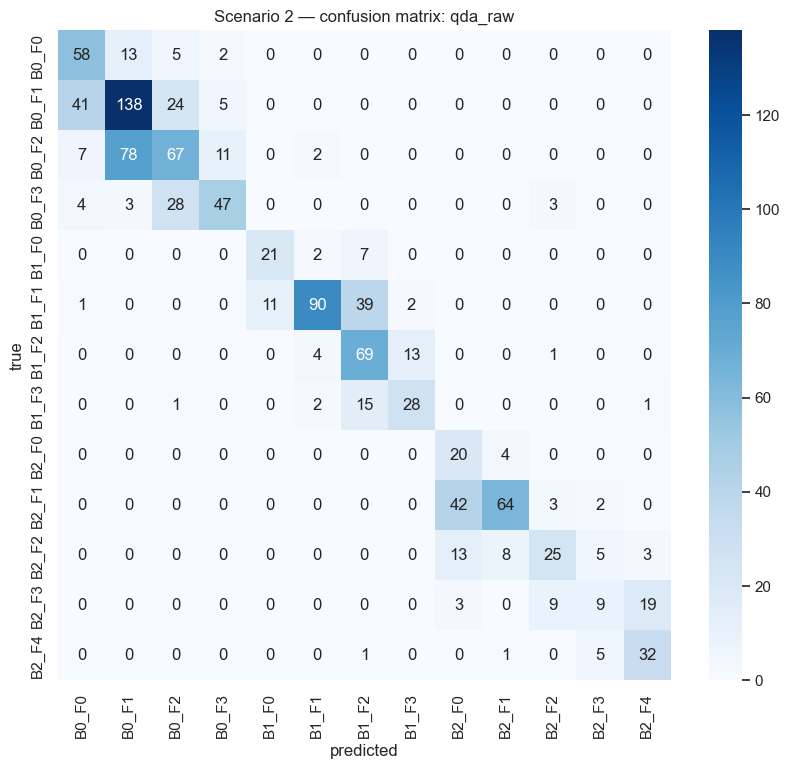

qda_raw                  family=parametric     bal_acc=0.616 macro_f1=0.583


In [6]:
try:
    qda_raw = M.build_qda(reg_param=1e-3)
    result = E.evaluate_classifier(
        qda_raw, Xs_tr, y_tr, Xs_va, y_va, name="qda_raw",
    )
    report_df = E.classification_report_to_dataframe(
        y_va, result.y_pred, labels=result.classes,
    )
    save_table(report_df, "scenario_2_classification_report_qda_raw.csv")
    P.plot_confusion_matrix(
        result,
        FIGURES_DIR / "scenario_2_confusion_matrix_qda_raw.png",
        title="Scenario 2 — confusion matrix: qda_raw",
    )
    results.append(result)
    fitted_models["qda_raw"] = qda_raw
    family_by_model["qda_raw"] = "parametric"
    print(
        f"qda_raw                  family=parametric     "
        f"bal_acc={result.metrics['balanced_accuracy']:.3f} "
        f"macro_f1={result.metrics['macro_f1']:.3f}"
    )
except Exception as exc:
    print(f"qda_raw FAILED: {type(exc).__name__}: {exc}")

## Metrics table

In [7]:
metrics_df = E.results_to_metrics_df(results)
metrics_df["family"] = metrics_df["model"].map(family_by_model)
ordered_cols = ["model", "family"] + [c for c in metrics_df.columns if c not in {"model", "family"}]
metrics_df = metrics_df[ordered_cols]
save_table(metrics_df, "scenario_2_model_metrics.csv")
display(metrics_df)

,model,family,accuracy,balanced_accuracy,macro_f1,weighted_f1,fit_seconds,predict_seconds,n_classes
0,random_forest,non_parametric,0.908191,0.892131,0.892380,0.909477,0.426148,0.027256,13
1,logistic_regression,parametric,0.882088,0.884657,0.869955,0.883697,0.224099,0.000902,13
2,lda,parametric,0.888389,0.871823,0.846671,0.890585,0.328724,0.000260,13
3,knn,non_parametric,0.793879,0.802673,0.793154,0.795831,0.027967,0.062718,13
4,qda_pca50,parametric,0.737174,0.767706,0.730904,0.742134,0.069533,0.001519,13
5,decision_tree,non_parametric,0.686769,0.664201,0.676364,0.701898,0.285124,0.000480,13
6,qda_raw,parametric,0.601260,0.615589,0.582956,0.603226,0.383462,0.012762,13


## Metric comparison plot

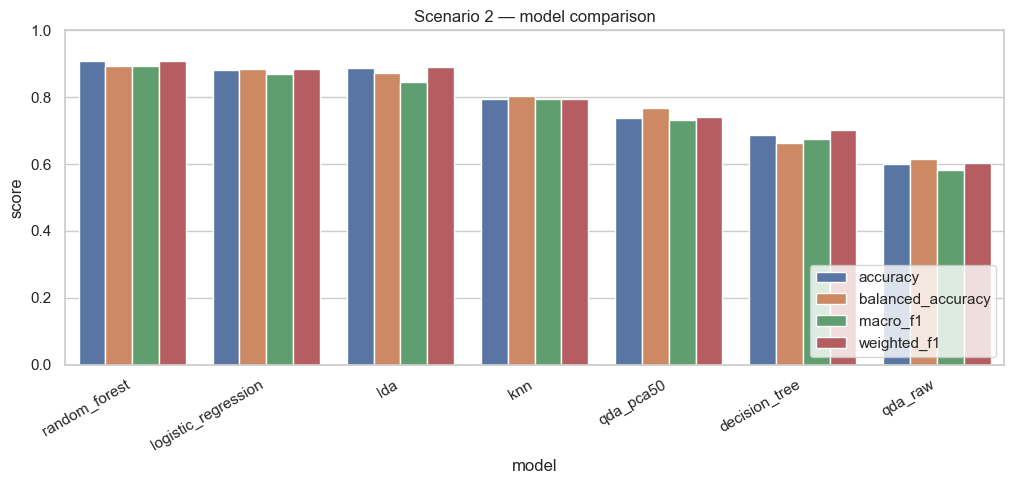

PosixPath('/Users/andrejvysny/fiit/oznal-python/reports/figures/scenario_2_metric_comparison.png')

In [8]:
P.plot_metric_comparison(
    metrics_df,
    FIGURES_DIR / "scenario_2_metric_comparison.png",
    title="Scenario 2 — model comparison",
)

## Select best parametric and non-parametric models

In [9]:
parametric_metrics = metrics_df[metrics_df["family"] == "parametric"]
non_parametric_metrics = metrics_df[metrics_df["family"] == "non_parametric"]

best_parametric = E.select_best_model(parametric_metrics)
best_non_parametric = E.select_best_model(non_parametric_metrics)

parametric_path = MODELS_DIR / "scenario_2_best_parametric.joblib"
non_parametric_path = MODELS_DIR / "scenario_2_best_non_parametric.joblib"
joblib.dump(fitted_models[best_parametric["model"]], parametric_path)
joblib.dump(fitted_models[best_non_parametric["model"]], non_parametric_path)

print(
    "Best parametric:", best_parametric["model"],
    f"(balanced_accuracy={best_parametric['balanced_accuracy']:.3f}, "
    f"macro_f1={best_parametric['macro_f1']:.3f}) -> {parametric_path}"
)
print(
    "Best non-parametric:", best_non_parametric["model"],
    f"(balanced_accuracy={best_non_parametric['balanced_accuracy']:.3f}, "
    f"macro_f1={best_non_parametric['macro_f1']:.3f}) -> {non_parametric_path}"
)

Best parametric: logistic_regression (balanced_accuracy=0.885, macro_f1=0.870) -> /Users/andrejvysny/fiit/oznal-python/models/scenario_2_best_parametric.joblib
Best non-parametric: random_forest (balanced_accuracy=0.892, macro_f1=0.892) -> /Users/andrejvysny/fiit/oznal-python/models/scenario_2_best_non_parametric.joblib


## Logistic Regression interpretability

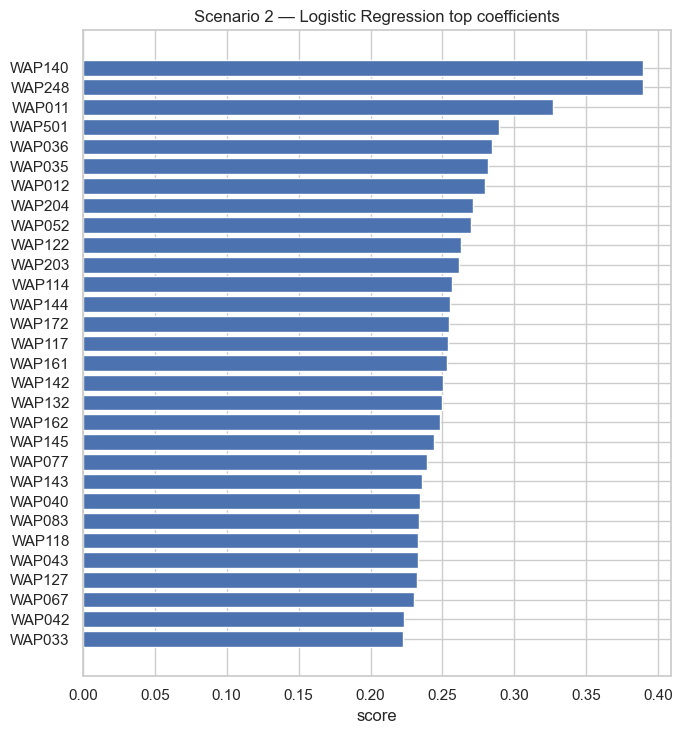

,wap,mean_abs_coef
0,WAP140,0.389762
1,WAP248,0.389609
2,WAP011,0.327086
3,WAP501,0.289358
4,WAP036,0.284656
5,WAP035,0.281629
6,WAP012,0.279593
7,WAP204,0.270996
8,WAP052,0.269630
9,WAP122,0.262998


In [10]:
if "logistic_regression" in fitted_models:
    fitted_model = fitted_models["logistic_regression"]
    coef = fitted_model.named_steps["classifier"].coef_
    lr_coef_df = (
        pd.DataFrame({
            "wap": prepared.kept_wap_columns,
            "mean_abs_coef": np.mean(np.abs(coef), axis=0),
        })
        .sort_values("mean_abs_coef", ascending=False)
        .head(30)
        .reset_index(drop=True)
    )
    save_table(lr_coef_df, "scenario_2_logistic_regression_coefficients.csv")
    P.plot_top_features(
        lr_coef_df.rename(columns={"wap": "feature", "mean_abs_coef": "score"}),
        FIGURES_DIR / "scenario_2_logistic_regression_top_coefficients.png",
        title="Scenario 2 — Logistic Regression top coefficients",
        feature_col="feature",
        score_col="score",
    )
    display(lr_coef_df)
else:
    print("Logistic Regression did not succeed; skipping coefficient export.")

## Random Forest interpretability

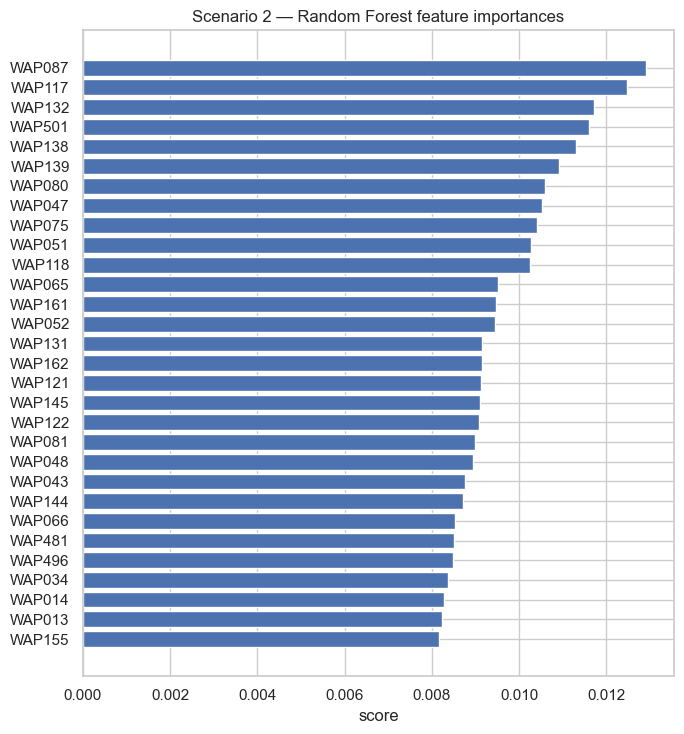

,wap,importance
0,WAP087,0.012908
1,WAP117,0.012482
2,WAP132,0.011721
3,WAP501,0.011599
4,WAP138,0.011316
5,WAP139,0.010920
6,WAP080,0.010587
7,WAP047,0.010521
8,WAP075,0.010409
9,WAP051,0.010267


In [11]:
if "random_forest" in fitted_models:
    fitted_model = fitted_models["random_forest"]
    importances = fitted_model.named_steps["classifier"].feature_importances_
    rf_importance_df = (
        pd.DataFrame({
            "wap": prepared.kept_wap_columns,
            "importance": importances,
        })
        .sort_values("importance", ascending=False)
        .head(30)
        .reset_index(drop=True)
    )
    save_table(rf_importance_df, "scenario_2_random_forest_feature_importances.csv")
    P.plot_top_features(
        rf_importance_df.rename(columns={"wap": "feature", "importance": "score"}),
        FIGURES_DIR / "scenario_2_random_forest_feature_importances.png",
        title="Scenario 2 — Random Forest feature importances",
        feature_col="feature",
        score_col="score",
    )
    display(rf_importance_df)
else:
    print("Random Forest did not succeed; skipping feature-importance export.")

## Interpretation and conclusion

This notebook produces one metric table, one classification report per
successful model, one confusion matrix per successful model, family-specific
best-model artifacts, and two interpretability exports. The final notebook
uses these fixed outputs to decide whether the extra flexibility of
non-parametric models is worth the explainability/runtime trade-off.